# Chunk1

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Configuration for 3 products
products = {
    'A': {'alpha': 500, 'beta': -1.1, 'gamma': 0.2, 'base_price': 100, 'cost': 60},
    'B': {'alpha': 300, 'beta': -0.8, 'gamma': 0.15, 'base_price': 150, 'cost': 90},
    'C': {'alpha': 800, 'beta': -1.4, 'gamma': 0.25, 'base_price': 50, 'cost': 25},
}

n_years = 3
dates = pd.date_range('2021-01-01', periods=365*n_years)

rows = []

for pid, params in products.items():
    alpha = params['alpha']
    beta = params['beta']
    gamma = params['gamma']  # cross-price elasticity
    base_price = params['base_price']
    cost_per_unit = params['cost']

    for d in dates:
        # Dynamic price with strong variation (±30%)
        price = base_price * np.random.uniform(0.7, 1.3)

        # Promotion effect
        promo = np.random.binomial(1, 0.2)  # 20% chance
        promotion_effect = 1.2 if promo else 1.0

        # Competitor price (slightly different + random noise)
        competitor_price = price * np.random.uniform(0.9, 1.1)

        # Seasonality: annual cycles
        day_of_year = d.timetuple().tm_yday
        seasonality = 0.3 * np.sin(2 * np.pi * day_of_year / 365)  # slightly stronger effect

        # Demand function: Q = alpha * P^beta * P_comp^gamma * exp(seasonality) * promotion_effect + noise
        quantity = alpha * (price ** beta) * (competitor_price ** gamma) * np.exp(seasonality) * promotion_effect
        quantity += np.random.normal(0, quantity * 0.02)  # reduced noise to 2%

        quantity = max(quantity, 1)  # avoid zeros

        rows.append({
            'date': d,
            'product_id': pid,
            'price': round(price, 2),
            'competitor_price': round(competitor_price, 2),
            'quantity_sold': round(quantity),
            'cost_per_unit': cost_per_unit,
            'promotion_flag': promo,
            'region': np.random.choice(['North', 'South', 'East', 'West'])
        })

df = pd.DataFrame(rows)

# Save to CSV
df.to_csv('synthetic_dynamic_pricing.csv', index=False)
print(df.head())
print("Dataset shape:", df.shape)


        date product_id   price  competitor_price  quantity_sold  \
0 2021-01-01          A   92.47             96.76             10   
1 2021-01-02          A   76.00             73.47             10   
2 2021-01-03          A  112.48            123.06              7   
3 2021-01-04          A  129.53            132.43              7   
4 2021-01-05          A   95.92             98.06              8   

   cost_per_unit  promotion_flag region  
0             60               1   East  
1             60               0   West  
2             60               0   West  
3             60               0  North  
4             60               0   West  
Dataset shape: (3285, 8)


# CHunk 2

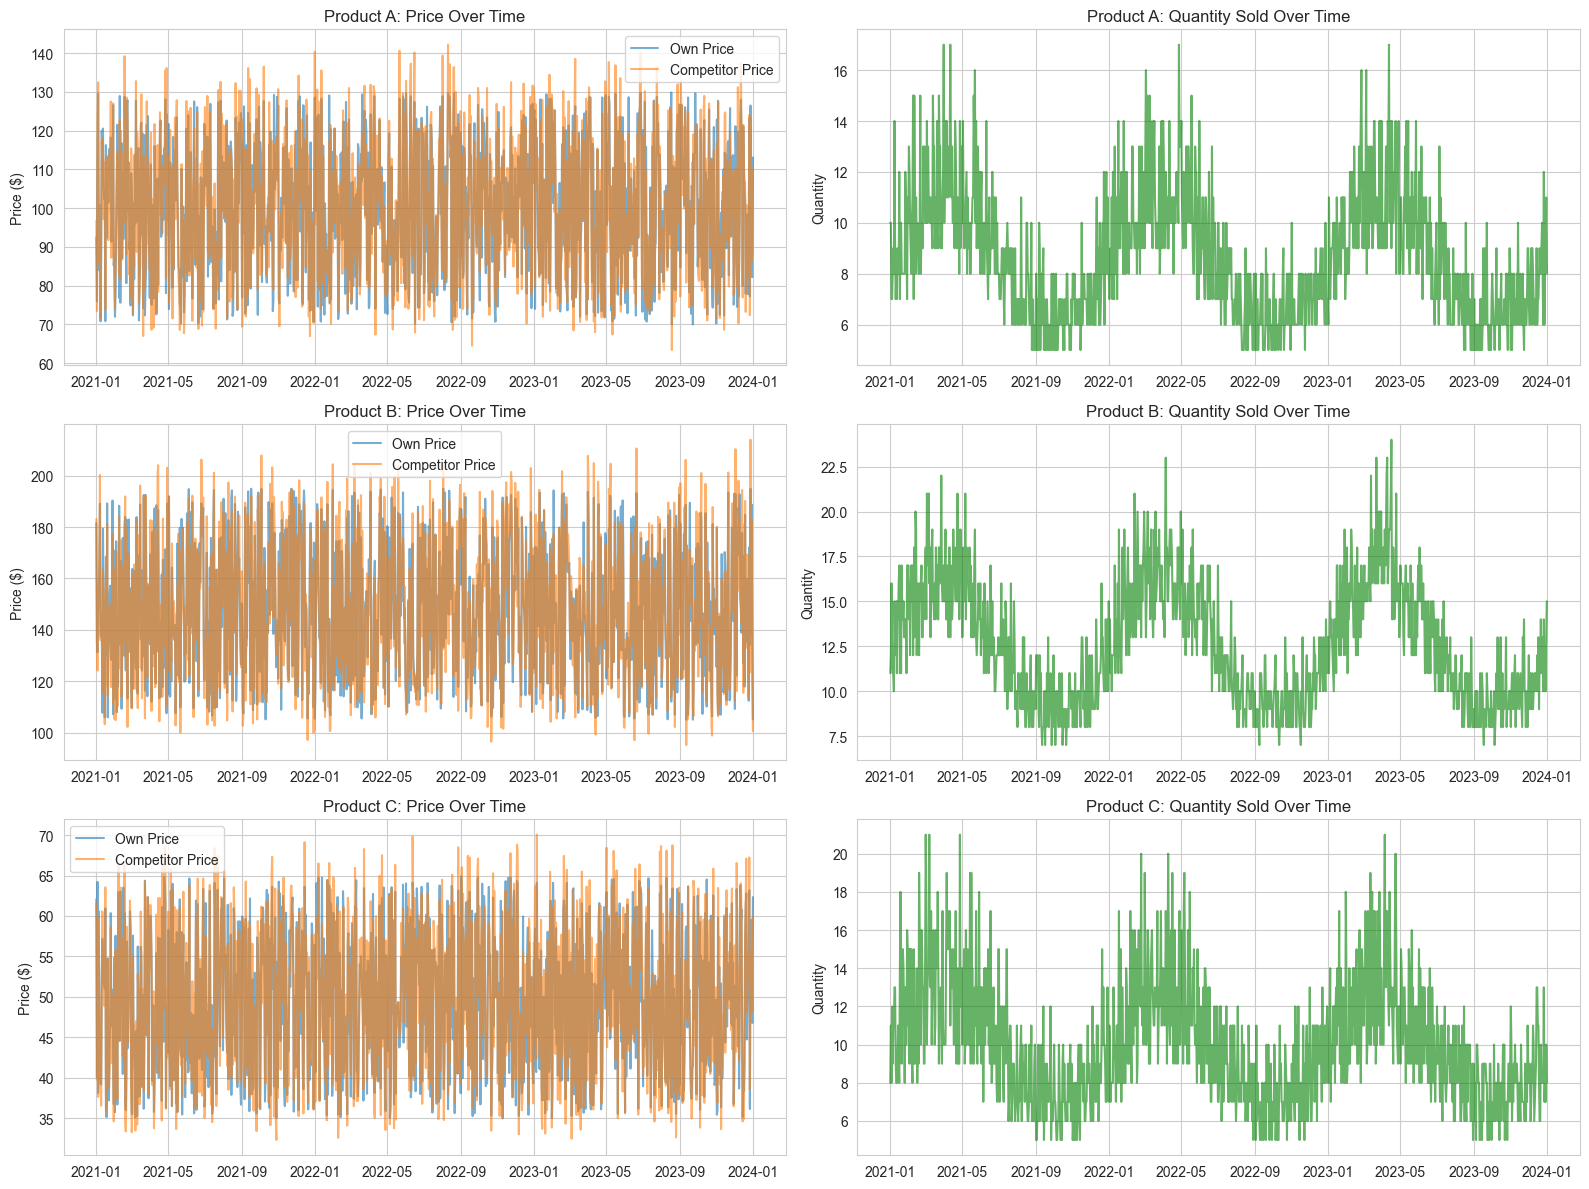

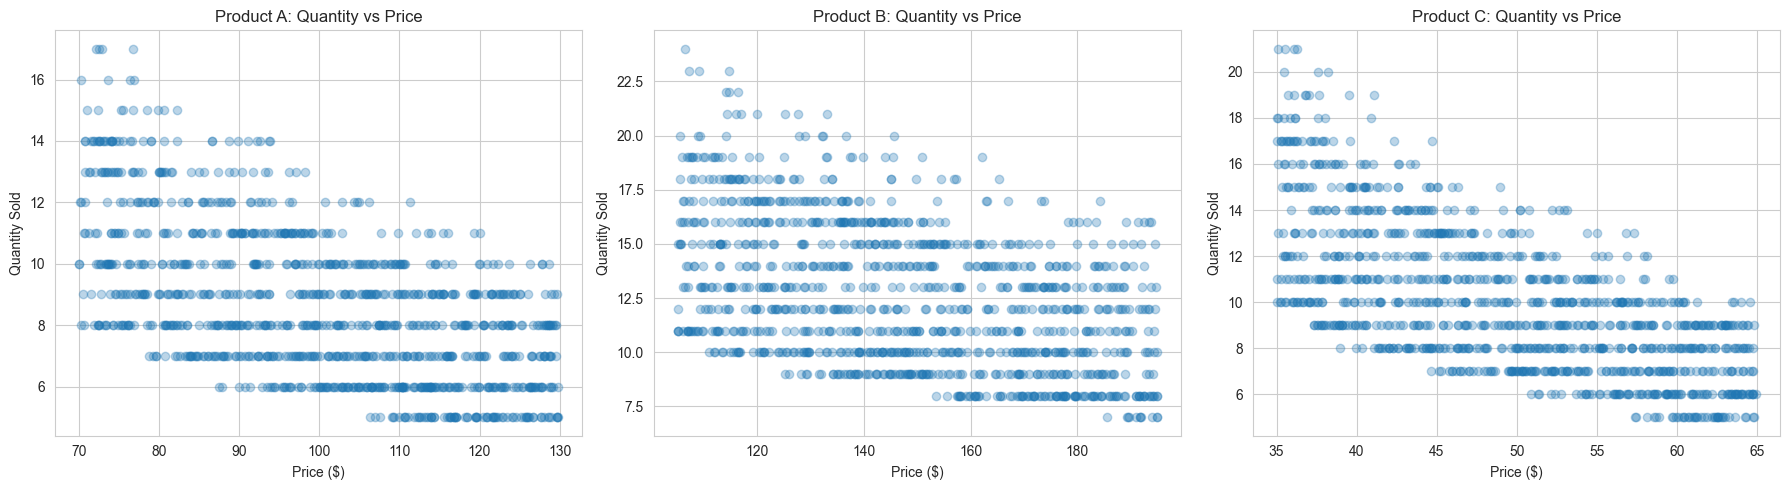


=== SUMMARY STATISTICS ===
             price                        quantity_sold                \
              mean    std     min     max          mean   std min max   
product_id                                                              
A           100.27  16.87   70.01  129.82          8.64  2.48   5  17   
B           148.35  25.73  105.02  194.98         12.60  3.30   7  24   
C            49.48   8.74   35.00   64.92         10.00  3.19   5  21   

           competitor_price        promotion_flag  
                       mean    std           mean  
product_id                                         
A                    100.53  17.95           0.20  
B                    148.38  27.06           0.20  
C                     49.67   9.20           0.21  

=== CORRELATION MATRIX ===
                  price  quantity_sold  competitor_price  promotion_flag
price             1.000          0.095             0.990          -0.004
quantity_sold     0.095          1.000         

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# 1. Price and Quantity over time
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for idx, pid in enumerate(['A', 'B', 'C']):
    product_data = df[df['product_id'] == pid].sort_values('date')
    
    # Price over time
    axes[idx, 0].plot(product_data['date'], product_data['price'], alpha=0.6, label='Own Price')
    axes[idx, 0].plot(product_data['date'], product_data['competitor_price'], alpha=0.6, label='Competitor Price')
    axes[idx, 0].set_title(f'Product {pid}: Price Over Time')
    axes[idx, 0].legend()
    axes[idx, 0].set_ylabel('Price ($)')
    
    # Quantity over time
    axes[idx, 1].plot(product_data['date'], product_data['quantity_sold'], alpha=0.6, color='green')
    axes[idx, 1].set_title(f'Product {pid}: Quantity Sold Over Time')
    axes[idx, 1].set_ylabel('Quantity')

plt.tight_layout()
plt.savefig('eda_timeseries.png', dpi=150)
plt.show()

# 2. Scatter: Quantity vs Price
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, pid in enumerate(['A', 'B', 'C']):
    product_data = df[df['product_id'] == pid]
    axes[idx].scatter(product_data['price'], product_data['quantity_sold'], alpha=0.3)
    axes[idx].set_title(f'Product {pid}: Quantity vs Price')
    axes[idx].set_xlabel('Price ($)')
    axes[idx].set_ylabel('Quantity Sold')

plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=150)
plt.show()

# 3. Summary Statistics
print("\n=== SUMMARY STATISTICS ===")
summary = df.groupby('product_id').agg({
    'price': ['mean', 'std', 'min', 'max'],
    'quantity_sold': ['mean', 'std', 'min', 'max'],
    'competitor_price': ['mean', 'std'],
    'promotion_flag': 'mean'
}).round(2)
print(summary)

# 4. Correlation Matrix
print("\n=== CORRELATION MATRIX ===")
corr_cols = ['price', 'quantity_sold', 'competitor_price', 'promotion_flag']
print(df[corr_cols].corr().round(3))

# Check for zeros
print(f"\n% of zero sales: {(df['quantity_sold'] == 0).mean() * 100:.2f}%")

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("synthetic_dynamic_pricing.csv")
print(df.head())
print(df.describe(include='all'))


         date product_id   price  competitor_price  quantity_sold  \
0  2021-01-01          A   92.47             96.76             10   
1  2021-01-02          A   76.00             73.47             10   
2  2021-01-03          A  112.48            123.06              7   
3  2021-01-04          A  129.53            132.43              7   
4  2021-01-05          A   95.92             98.06              8   

   cost_per_unit  promotion_flag region  
0             60               1   East  
1             60               0   West  
2             60               0   West  
3             60               0  North  
4             60               0   West  
              date product_id        price  competitor_price  quantity_sold  \
count         3285       3285  3285.000000       3285.000000    3285.000000   
unique        1095          3          NaN               NaN            NaN   
top     2021-01-01          A          NaN               NaN            NaN   
freq             

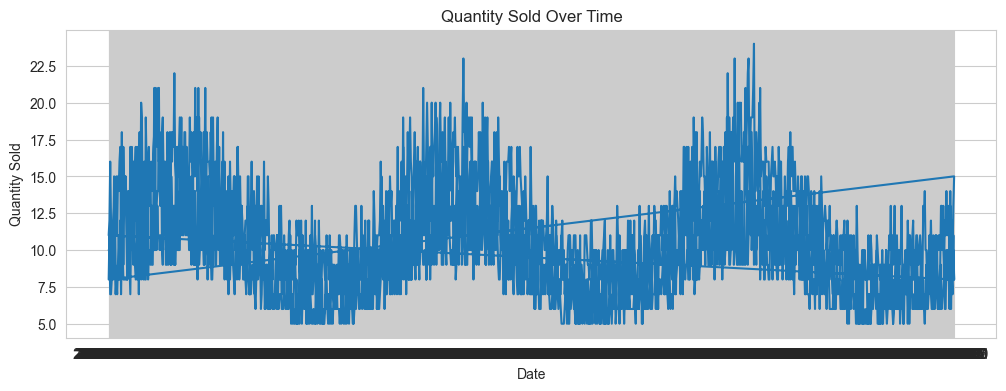

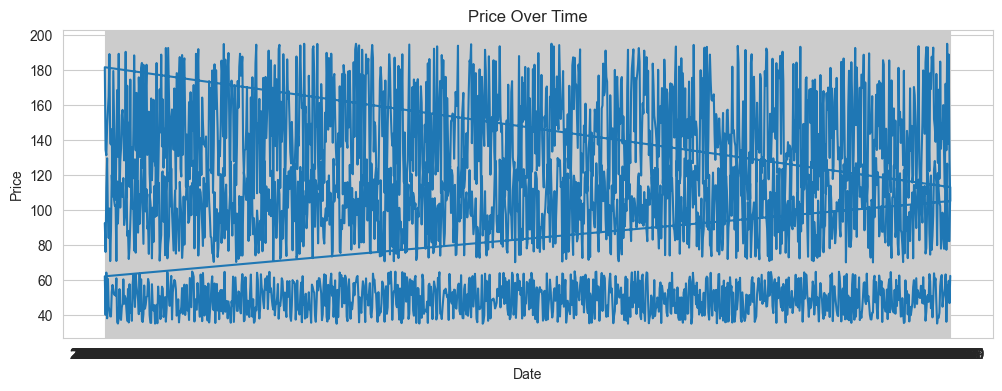

In [5]:
# Quantity over time
plt.figure(figsize=(12,4))
plt.plot(df['date'], df['quantity_sold'])
plt.title('Quantity Sold Over Time')
plt.xlabel('Date'); plt.ylabel('Quantity Sold')
plt.show()

# Price over time
plt.figure(figsize=(12,4))
plt.plot(df['date'], df['price'])
plt.title('Price Over Time')
plt.xlabel('Date'); plt.ylabel('Price')
plt.show()


In [6]:
print(df[['price','quantity_sold','competitor_price']].describe())
print("Percentage of zero sales:", 
      (df['quantity_sold']==0).mean()*100)


             price  quantity_sold  competitor_price
count  3285.000000    3285.000000       3285.000000
mean     99.365900      10.411872         99.525836
std      44.392746       3.430346         44.768373
min      35.000000       5.000000         32.280000
25%      57.190000       8.000000         57.130000
50%     100.610000      10.000000         99.480000
75%     128.630000      13.000000        130.260000
max     194.980000      24.000000        214.050000
Percentage of zero sales: 0.0


# CHunk 3

##### since dataset is synthetic no need for cleaning

In [7]:
zero_count = (df['quantity_sold']==0).sum()
print(f"Zero-quantity rows: {zero_count} ({zero_count/len(df)*100:.2f}%)")


Zero-quantity rows: 0 (0.00%)


# Chunk 4

In [8]:
import numpy as np

epsilon = 0.1
df['log_quantity'] = np.log(df['quantity_sold'] + epsilon)
df['log_price'] = np.log(df['price'])
df['log_competitor_price'] = np.log(df['competitor_price'])


In [9]:
%pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import statsmodels.api as sm

# Basic model: log(Q) ~ log(P)
X = sm.add_constant(df['log_price'])   # adds intercept
y = df['log_quantity']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           log_quantity   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     5.244
Date:                Sat, 25 Oct 2025   Prob (F-statistic):             0.0221
Time:                        17:11:13   Log-Likelihood:                -952.54
No. Observations:                3285   AIC:                             1909.
Df Residuals:                    3283   BIC:                             1921.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1814      0.052     41.742      0.0

In [11]:
X2 = sm.add_constant(df[['log_price','log_competitor_price']])
y = df['log_quantity']

model2 = sm.OLS(y, X2).fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:           log_quantity   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.744
Date:                Sat, 25 Oct 2025   Prob (F-statistic):             0.0645
Time:                        17:11:13   Log-Likelihood:                -952.41
No. Observations:                3285   AIC:                             1911.
Df Residuals:                    3282   BIC:                             1929.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    2.1808 

In [12]:
alpha_hat = np.exp(model.params['const'])
beta_hat = model.params['log_price']
print(f"α (intercept as level): {alpha_hat:.3f}")
print(f"β (price elasticity): {beta_hat:.3f}")


α (intercept as level): 8.859
β (price elasticity): 0.027


In [13]:
print(f"R²: {model.rsquared:.3f}")

R²: 0.002


In [14]:

import pandas as pd
import numpy as np
import statsmodels.api as sm

# Create seasonality features (sin/cos of day of year)
df['date'] = pd.to_datetime(df['date'])
df['day_of_year'] = df['date'].dt.dayofyear
df['sin_doy'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['cos_doy'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

# Regression model
X = df[['log_price', 'log_competitor_price', 'promotion_flag', 'sin_doy', 'cos_doy']]
X = sm.add_constant(X)
y = df['log_quantity']

model = sm.OLS(y, X).fit()
print(model.summary())

# Extract coefficients
alpha_hat = np.exp(model.params['const'])
beta_hat = model.params['log_price']
print(f"α (intercept as level): {alpha_hat:.3f}")
print(f"β (own-price elasticity): {beta_hat:.3f}")


                            OLS Regression Results                            
Dep. Variable:           log_quantity   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     657.6
Date:                Sat, 25 Oct 2025   Prob (F-statistic):               0.00
Time:                        17:11:16   Log-Likelihood:                 185.59
No. Observations:                3285   AIC:                            -359.2
Df Residuals:                    3279   BIC:                            -322.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    2.1147 

In [15]:
# Extract coefficients
alpha_hat = np.exp(model.params['const'])
beta_hat = model.params['log_price']
beta_comp = model.params['log_competitor_price']
beta_promo = model.params['promotion_flag']
beta_sin = model.params['sin_doy']
beta_cos = model.params['cos_doy']

print("Estimated coefficients:")
print(f"α (intercept as level): {alpha_hat:.3f}")
print(f"β (own-price elasticity): {beta_hat:.3f}")
print(f"γ (competitor-price effect): {beta_comp:.3f}")
print(f"δ (promotion effect): {beta_promo:.3f}")
print(f"θ1 (seasonality sine): {beta_sin:.3f}")
print(f"θ2 (seasonality cosine): {beta_cos:.3f}")


Estimated coefficients:
α (intercept as level): 8.287
β (own-price elasticity): -0.101
γ (competitor-price effect): 0.134
δ (promotion effect): 0.174
θ1 (seasonality sine): 0.307
θ2 (seasonality cosine): -0.003


In [16]:
# Fit separate models per product
for pid in ['A', 'B', 'C']:
    product_data = df[df['product_id'] == pid]
    X_prod = product_data[['log_price', 'log_competitor_price', 'promotion_flag', 'sin_doy', 'cos_doy']]
    X_prod = sm.add_constant(X_prod)
    y_prod = product_data['log_quantity']
    
    model_prod = sm.OLS(y_prod, X_prod).fit()
    beta_prod = model_prod.params['log_price']
    pval_prod = model_prod.pvalues['log_price']
    
    print(f"\n=== PRODUCT {pid} ===")
    print(f"β (own-price elasticity): {beta_prod:.3f}")
    print(f"p-value: {pval_prod:.4f}")
    print(f"True β (from generation): {products[pid]['beta']}")


=== PRODUCT A ===
β (own-price elasticity): -1.033
p-value: 0.0000
True β (from generation): -1.1

=== PRODUCT B ===
β (own-price elasticity): -0.824
p-value: 0.0000
True β (from generation): -0.8

=== PRODUCT C ===
β (own-price elasticity): -1.373
p-value: 0.0000
True β (from generation): -1.4
